# TyreVisionX Dataset Exploration (Day 2)

This notebook performs dataset stats, visualization, and quality checks.

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATASET_ROOT = Path('data/raw/D1_tyrenet')
MANIFEST_PATH = Path('data/processed/D1_manifest.csv')

def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for parent in candidates:
        if (parent / "data").exists() and (parent / "src").exists():
            return parent
        candidate = parent / "TyreVisionX"
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    return start

repo_root = find_repo_root(Path.cwd())
DATASET_ROOT = DATASET_ROOT if DATASET_ROOT.is_absolute() else repo_root / DATASET_ROOT
MANIFEST_PATH = MANIFEST_PATH if MANIFEST_PATH.is_absolute() else repo_root / MANIFEST_PATH

print("cwd:", Path.cwd())
print("repo_root:", repo_root)
print("dataset_root:", DATASET_ROOT)
print("manifest_path:", MANIFEST_PATH)

if not MANIFEST_PATH.exists():
    print('Manifest not found. Run: python scripts/prepare_manifests.py --dataset_root data/raw/D1_tyrenet --out_csv data/processed/D1_manifest.csv')

def resolve_path(rel_path: str) -> Path:
    p = Path(rel_path)
    if p.is_absolute():
        return p
    candidate = repo_root / p
    if candidate.exists():
        return candidate
    return DATASET_ROOT / p


cwd: /Users/ritik/Documents/Project TDA/TyreVisionX/notebooks
repo_root: /Users/ritik/Documents/Project TDA/TyreVisionX
dataset_root: /Users/ritik/Documents/Project TDA/TyreVisionX/data/raw/D1_tyrenet
manifest_path: /Users/ritik/Documents/Project TDA/TyreVisionX/data/processed/D1_manifest.csv


In [11]:
# Optional: run manifest generation from notebook
import subprocess

cmd = [
    'python', 'scripts/prepare_manifests.py',
    '--dataset_root', str(DATASET_ROOT),
    '--dataset_id', 'D1',
    '--good_dir', 'good',
    '--defect_dir', 'defect',
    '--out_csv', str(MANIFEST_PATH),
]
# Uncomment to run
# subprocess.run(cmd, check=True)


In [12]:
# Dataset stats
if not MANIFEST_PATH.exists():
    raise FileNotFoundError('Manifest missing. Run the manifest script first.')

df = pd.read_csv(MANIFEST_PATH)
total_images = len(df)
label_counts = df['label_str'].value_counts()
split_counts = df.groupby(['split', 'label_str']).size().unstack(fill_value=0)

print('Total images:', total_images)
print('Class counts:\n', label_counts)
print('Split counts per class:\n', split_counts)


Total images: 1698
Class counts:
 label_str
defect    866
good      832
Name: count, dtype: int64
Split counts per class:
 label_str  defect  good
split                  
test          130   125
train         606   582
val           130   125


Width min/max/mean: 1100 2268 2147.9266666666667
Height min/max/mean: 1100 2268 2147.9266666666667


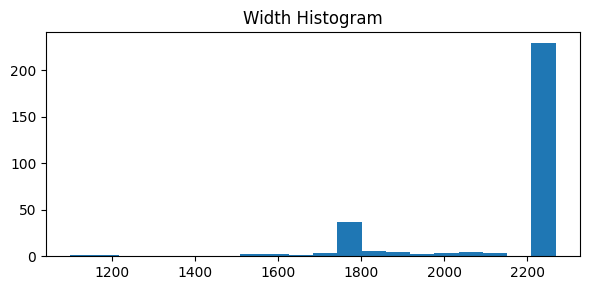

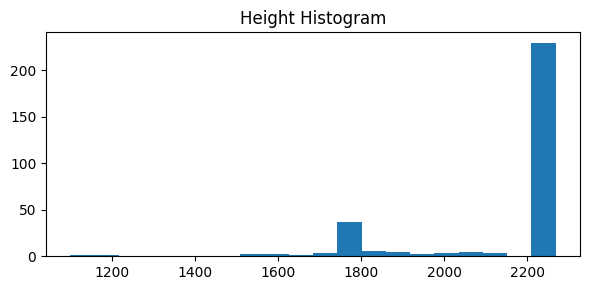

In [13]:
# Resolution stats (sample first N images)
N = min(300, len(df))
sample_paths = df['image_path'].head(N).tolist()

widths = []
heights = []
for rel_path in sample_paths:
    img_path = resolve_path(rel_path)
    if not img_path.exists():
        continue
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print('Width min/max/mean:', np.min(widths), np.max(widths), np.mean(widths))
print('Height min/max/mean:', np.min(heights), np.max(heights), np.mean(heights))

plt.figure(figsize=(6, 3))
plt.hist(widths, bins=20)
plt.title('Width Histogram')
plt.tight_layout()

plt.figure(figsize=(6, 3))
plt.hist(heights, bins=20)
plt.title('Height Histogram')
plt.tight_layout()


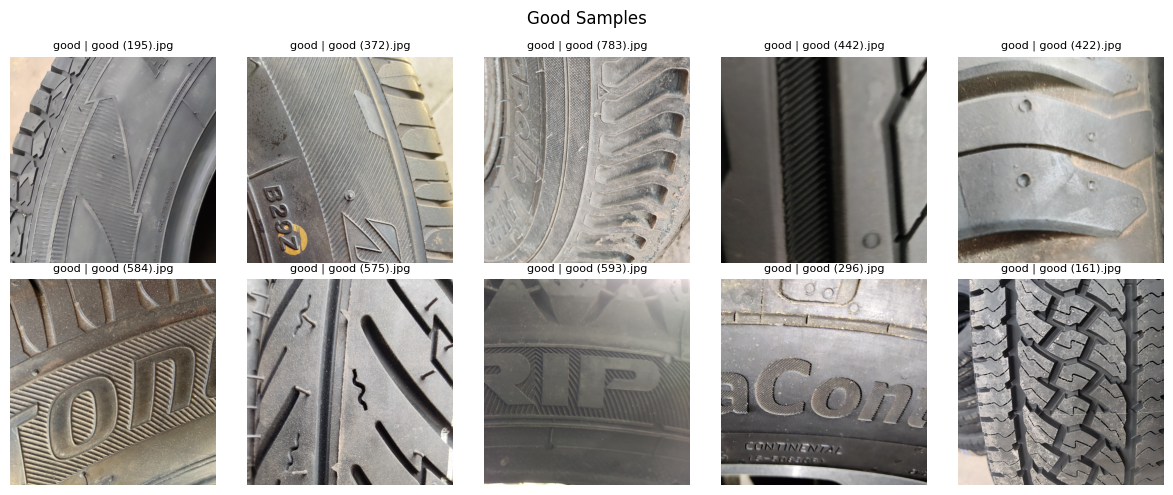

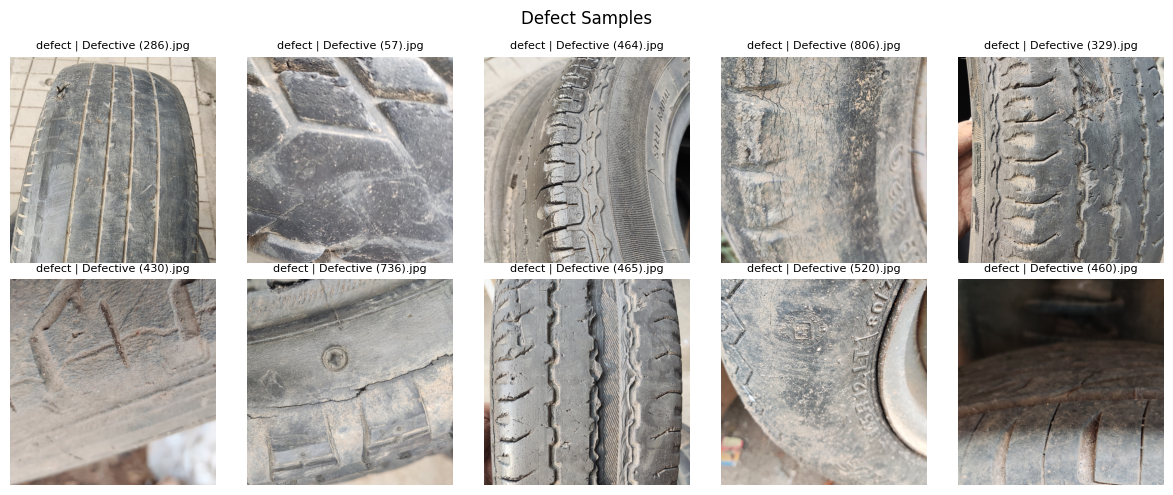

In [14]:
# Visualize samples (10 good + 10 defect)
def show_samples(subset_df, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title)
    for ax, (_, row) in zip(axes.flatten(), subset_df.iterrows()):
        img_path = resolve_path(row['image_path'])
        with Image.open(img_path) as img:
            ax.imshow(img)
        ax.set_title(f"{row['label_str']} | {Path(row['image_path']).name}", fontsize=8)
        ax.axis('off')
    plt.tight_layout()

good_samples = df[df['label_str'] == 'good'].sample(10, random_state=42)
defect_samples = df[df['label_str'] == 'defect'].sample(10, random_state=42)
show_samples(good_samples, 'Good Samples')
show_samples(defect_samples, 'Defect Samples')


In [15]:
# Quality checks: brightness and blur
import cv2

scores = []
for _, row in df.iterrows():
    img_path = resolve_path(row['image_path'])
    if not img_path.exists():
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())
    blur = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    scores.append({
        'image_path': row['image_path'],
        'brightness': brightness,
        'blur': blur,
        'label_str': row['label_str'],
    })

score_df = pd.DataFrame(scores)
darkest = score_df.nsmallest(10, 'brightness')
blurriest = score_df.nsmallest(10, 'blur')

print('Top 10 darkest images:')
print(darkest[['image_path', 'brightness', 'blur']])
print('Top 10 blurriest images:')
print(blurriest[['image_path', 'brightness', 'blur']])


Top 10 darkest images:
                        image_path  brightness        blur
606   data/raw/good/good (225).jpg   54.028675   39.443861
1363  data/raw/good/good (340).jpg   54.781199  201.453068
878   data/raw/good/good (227).jpg   55.185809   37.108146
497   data/raw/good/good (317).jpg   55.552107  106.117741
1381  data/raw/good/good (221).jpg   61.881715   49.165635
710   data/raw/good/good (305).jpg   61.890134   54.011779
253   data/raw/good/good (293).jpg   63.655079   28.717271
872   data/raw/good/good (224).jpg   64.204237   36.499879
165   data/raw/good/good (304).jpg   65.030090   49.250116
1081  data/raw/good/good (307).jpg   66.453451   48.523292
Top 10 blurriest images:
                               image_path  brightness       blur
443   data/raw/defect/Defective (186).jpg  168.460883   9.475305
745   data/raw/defect/Defective (188).jpg  162.106190  10.033648
1148         data/raw/good/good (446).jpg  105.254517  10.161849
1251  data/raw/defect/Defective (146).jpg  

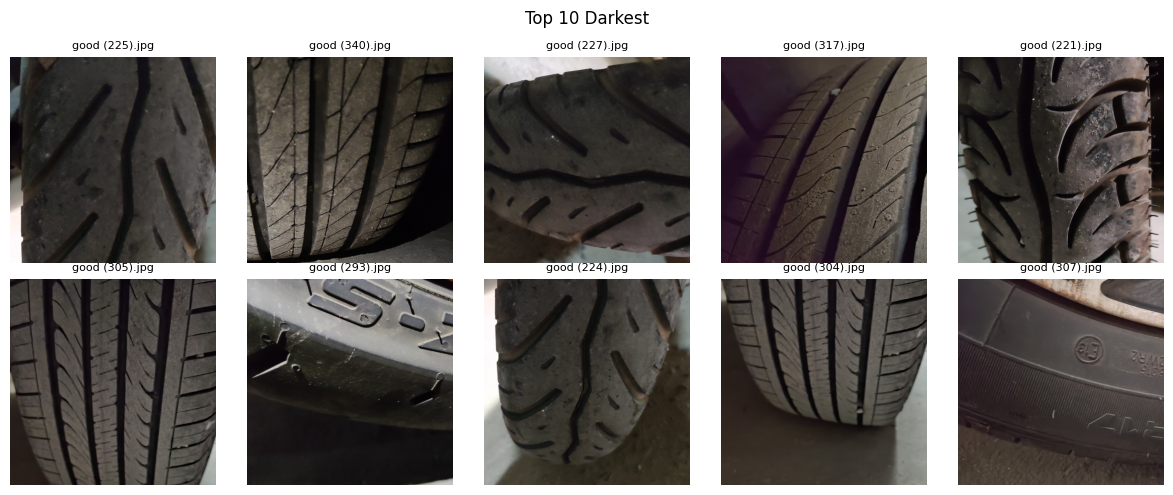

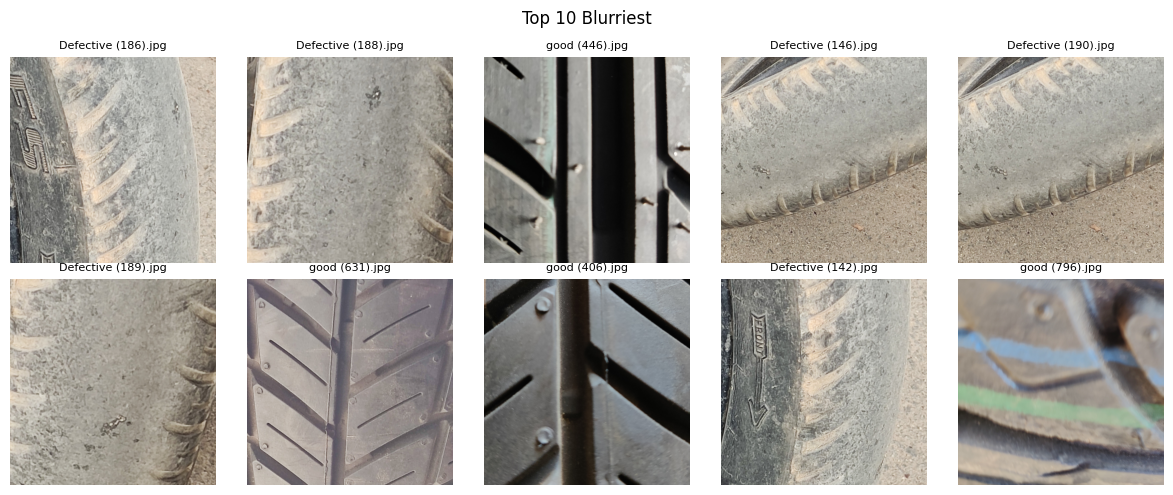

In [16]:
# Show thumbnails for darkest and blurriest
def show_thumbnail_grid(rows, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title)
    for ax, (_, row) in zip(axes.flatten(), rows.iterrows()):
        img_path = resolve_path(row['image_path'])
        with Image.open(img_path) as img:
            ax.imshow(img)
        ax.set_title(Path(row['image_path']).name, fontsize=8)
        ax.axis('off')
    plt.tight_layout()

show_thumbnail_grid(darkest, 'Top 10 Darkest')
show_thumbnail_grid(blurriest, 'Top 10 Blurriest')


## Decision Prompt
Choose the defaults for Day-3 training:

- RGB vs grayscale
- img_size (224 vs 384)
- augmentation preset (light vs strong)

**Recommended defaults**: RGB + 384 if defects are subtle; 224 for faster iteration. Use light aug first.